<a href="https://colab.research.google.com/github/E-tech-coder/DataScienceCapstoneProject/blob/Michi_v2/Feature_Engineering_Embedding_Random_Forest_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Feature Engineering + Random Forest Model**

Although the project description suggests incorporating historical job information, the labeled CSV files do not contain temporal or person-level data. Therefore, assumptions such as increasing seniority over time cannot be learned from data without label leakage.

In [ ]:
!git clone https://github.com/E-tech-coder/DataScienceCapstoneProject.git

Cloning into 'DataScienceCapstoneProject'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 238 (delta 102), reused 20 (delta 20), pack-reused 88 (from 1)
Receiving objects: 100% (238/238), 1.71 MiB | 7.86 MiB/s, done.
Resolving deltas: 100% (135/135), done.


In [ ]:
%cd DataScienceCapstoneProject
!git checkout Michi_v2

/content/DataScienceCapstoneProject/DataScienceCapstoneProject/DataScienceCapstoneProject/DataScienceCapstoneProject/DataScienceCapstoneProject
Branch 'Michi_v2' set up to track remote branch 'Michi_v2' from 'origin'.
Switched to a new branch 'Michi_v2'


In [ ]:
!ls

department.csv			       linkedin-cvs-not-annotated.json
df_profiles_cleansed.csv	       README.md
FeatureEngineering+RandomForest.ipynb  rule_based_matching_baseline.ipynb
linkedin-cvs-annotated.json	       rulebasedmodel_extended_v2.ipynb
linkedin-cvs-annotatedV5.csv	       seniority.csv
linkedin-cvs-not-annotated.csv


The files department.csv and seniority.csv are used for this machine learning model. The models for department and seniority are trained separately, resulting in two independent models. However, preprocessing, feature engineering and other preprocessing steps are applied uniformly for both models.

In [ ]:
import pandas as pd
from collections import Counter
import re
import numpy as np

#define files
df_sen = pd.read_csv("seniority.csv")
df_dep = pd.read_csv("department.csv")

In [ ]:
print("seniority columns:", df_sen.columns.tolist())
print("department columns:", df_dep.columns.tolist())

seniority columns: ['text', 'label']
department columns: ['text', 'label']


In [ ]:
print("\nSeniority class distribution:", Counter(df_sen["label"]))
print("Department class distribution:", Counter(df_dep["label"]))


Seniority class distribution: Counter({'Senior': 3733, 'Lead': 3546, 'Director': 984, 'Management': 756, 'Junior': 409})
Department class distribution: Counter({'Marketing': 4295, 'Sales': 3328, 'Information Technology': 1305, 'Business Development': 620, 'Project Management': 201, 'Consulting': 167, 'Administrative': 83, 'Other': 42, 'Purchasing': 40, 'Customer Support': 33, 'Human Resources': 31})


# **Text Normalization**

In [ ]:
#remove german umlauts
GERMAN_MAP = str.maketrans({
    "ä": "ae", "ö": "oe", "ü": "ue", "ß": "ss",
    "Ä": "ae", "Ö": "oe", "Ü": "ue"
})

#pipeline
def normalize_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.lower()
    text = text.translate(GERMAN_MAP)
    text = re.sub(r"[\/\-\|\&\(\)\[\],]", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [ ]:
#apply text normalization on data
df_sen["text_norm"] = df_sen["text"].apply(normalize_text)
df_dep["text_norm"] = df_dep["text"].apply(normalize_text)

# **Implementing Structure Features**

First, we implement simple numerical features that are language-independent. In particular, they help to reflect differences between short entry-level roles (‘analyst’) and longer, more complex role titles (‘senior manager corporate strategy’) and complement semantic embeddings in a meaningful way.
*   title_length_chars – number of characters
*   title_word_count – number of words
*   avg_word_length – average word length



In [ ]:
#defining features
def extract_structure_features(norm_text: str) -> dict:
    if pd.isna(norm_text):
        norm_text = ""

    words = norm_text.split()
    word_lengths = [len(w) for w in words] if words else [0]

    return {
        "title_length_chars": len(norm_text),
        "title_word_count": len(words),
        "avg_word_length": sum(word_lengths) / len(word_lengths)
    }

In [ ]:
#apply features to the data sets
def add_structure_features(df):
    feats = df["text_norm"].apply(extract_structure_features)
    feats_df = pd.DataFrame(list(feats))
    return pd.concat([df.reset_index(drop=True), feats_df], axis=1)

df_sen = add_structure_features(df_sen)
df_dep = add_structure_features(df_dep)

In [ ]:
#mid-term review
display(df_sen.head(3))
display(df_dep.head(3))

,text,label,text_norm,title_length_chars,title_word_count,avg_word_length
0,Analyst,Junior,analyst,7,1,7.0
1,Analyste financier,Junior,analyste financier,18,2,8.5
2,Anwendungstechnischer Mitarbeiter,Junior,anwendungstechnischer mitarbeiter,33,2,16.0


,text,label,text_norm,title_length_chars,title_word_count,avg_word_length
0,Adjoint directeur communication,Marketing,adjoint directeur communication,31,3,9.666667
1,Advisor Strategy and Projects,Project Management,advisor strategy and projects,29,4,6.500000
2,Beratung & Projekte,Project Management,beratung projekte,17,2,8.000000


# **Implementing Keyword Features**

We also implement numerical keyword count features to achieve a higher probability of correct classification for obvious hits. The keyword list is taken from the extended rule-based model, as a high matched accuracy has already been achieved there.

In [ ]:
#defining keywords for seniority
SENIORITY_KEYWORDS = {
    "management": [
        "ceo","cfo","cto","cmo","chief","vice","president","owner",
        "gesellschafter","founder","cofounder","co-founder","prokurist",
        "prokuristin","unternehmensinhaber","gesch"],
    "director": [
        "director","executive director","global director","finance director","strategy director"],
    "lead": [
        "lead","leitung","leiter","head"],
    "senior": [
        "senior","sr"],
    "junior": [
        "intern","junior","trainee","student","referent","auszubild"]
}

In [ ]:
#defining keywords for department
DEPARTMENT_KEYWORDS = {
    "administrative": [
        "assistentin","assistenz","assistent","office","assistant",
        "sekret","verwaltung","bueroleiter","facility","administrador"],
    "business_development": [
        "business development","business developer",
        "new business","strategic partnerships","bd"],
    "consulting": [
        "consultant","berater","sap","dynamics","erp"],
    "customer_support": [
        "support","customer","supporter"],
    "information technology": [
        "software","developer","engineer","architect","devops","cloud",
        "data scientist","data engineer","network",
        "systems administrator","administrator","it"],
    "human resources": [
        "human","resources","ressource","hr","personal",
        "recruitment","talent","personalleiter"],
    "marketing": [
        "marketing","communication","communications",
        "kommunikation","messe","event"],
    "project_management": [
        "project","projektleiter","projektmanager",
        "projektmanagement","projektleitung","projects"],
    "purchasing": [
        "einkauf","purchas","eink"],
    "sales": [
        "sales","vertrieb","vertriebsleiter","salesforce"]
}

In [ ]:
#keyword counting with word boundaries
def count_keywords_regex(text_norm: str, keyword_dict: dict) -> dict:
    if pd.isna(text_norm):
        text_norm = ""

    feats = {}
    for group, keywords in keyword_dict.items():
        count = 0
        for kw in keywords:
            pattern = rf"\b{re.escape(kw)}\b"
            count += len(re.findall(pattern, text_norm))
        feats[f"{group}_keyword_count"] = count

    return feats

In [ ]:
#apply features on dataset
def add_keyword_features(df):
    sen_feats = df["text_norm"].apply(
        lambda t: count_keywords_regex(t, SENIORITY_KEYWORDS)
    )
    dep_feats = df["text_norm"].apply(
        lambda t: count_keywords_regex(t, DEPARTMENT_KEYWORDS)
    )

    sen_df = pd.DataFrame(list(sen_feats)).add_prefix("sen_")
    dep_df = pd.DataFrame(list(dep_feats)).add_prefix("dep_")

    return pd.concat([df.reset_index(drop=True), sen_df, dep_df], axis=1)

df_sen = add_keyword_features(df_sen)
df_dep = add_keyword_features(df_dep)

# **Implementing Multilingual Word Embeddings**

We use multilingual embeddings in the following, as they can capture semantic similarities between job titles regardless of language. Multilingual sentence embeddings were calculated for each normalised job title. These embeddings represent the semantic meaning of the title in a dense numerical vector space.

In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

In [ ]:
#Calculate embeddings for job titles
def compute_embeddings(texts, model):
    return model.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False
    )

In [ ]:
#apply on both data sets
X_sen_emb = compute_embeddings(df_sen["text_norm"].tolist(), embedding_model)
X_dep_emb = compute_embeddings(df_dep["text_norm"].tolist(), embedding_model)

print(X_sen_emb.shape)
print(X_dep_emb.shape)

Batches:   0%|          | 0/295 [00:00<?, ?it/s]

Batches:   0%|          | 0/318 [00:00<?, ?it/s]

(9428, 384)
(10145, 384)


We have 384 dimensions. This is computationally intensive and may be partially redundant. We break the dimensions down to 50. However, we only fit PCA after the train-test split.

In [ ]:
from sklearn.decomposition import PCA

#pca dimension reduction
N_PCA_COMPONENTS = 50

pca = PCA(
    n_components=N_PCA_COMPONENTS,
    random_state=42
)

# **Seniority Model**

First, we will finalise the model for seniority.

**Train/Test Split**

Now we will split the data sets into train and test data. We will then only apply PCA to train, to avoid feature larning on test data and data leakage.

In [ ]:
from sklearn.model_selection import train_test_split

#train/test split
y_sen = df_sen["label"].values

idx_train_sen, idx_test_sen = train_test_split(
    np.arange(len(df_sen)),
    test_size=0.2,
    random_state=42,
    stratify=y_sen
)

print("Train size:", len(idx_train_sen))
print("Test size:", len(idx_test_sen))

Train size: 7542
Test size: 1886


In [ ]:
#pca on train data & transforming train/test
N_PCA_COMPONENTS = 50
pca_sen = PCA(n_components=N_PCA_COMPONENTS, random_state=42)

X_sen_train_emb = X_sen_emb[idx_train_sen]
X_sen_test_emb  = X_sen_emb[idx_test_sen]

X_sen_train_pca = pca_sen.fit_transform(X_sen_train_emb)
X_sen_test_pca  = pca_sen.transform(X_sen_test_emb)

print("PCA train shape:", X_sen_train_pca.shape)
print("PCA test shape:", X_sen_test_pca.shape)
print("Explained variance (sum):", round(pca_sen.explained_variance_ratio_.sum(), 4))

PCA train shape: (7542, 50)
PCA test shape: (1886, 50)
Explained variance (sum): 0.847


With only 50 PCA components, around 85% of the total variance of the original 384-dimensional sentence embeddings can be retained, indicating efficient dimension reduction with high information content.

**Build feature matrix**

In [ ]:
#structure features
STRUCT_COLS = ["title_length_chars", "title_word_count", "avg_word_length"]

#keyword count columns
SEN_KEYWORD_COLS = [c for c in df_sen.columns if c.startswith("sen_") and c.endswith("_keyword_count")]

print("Num structure features:", len(STRUCT_COLS))
print("Num keyword features:", len(SEN_KEYWORD_COLS))

Num structure features: 3
Num keyword features: 5


In [ ]:
#add features
X_sen_struct_kw = df_sen[STRUCT_COLS + SEN_KEYWORD_COLS].values

X_sen_train_struct_kw = X_sen_struct_kw[idx_train_sen]
X_sen_test_struct_kw  = X_sen_struct_kw[idx_test_sen]

print("Train structure + sen_kw:", X_sen_train_struct_kw.shape)
print("Test structure + sen_kw:", X_sen_test_struct_kw.shape)

Train structure + sen_kw: (7542, 8)
Test structure + sen_kw: (1886, 8)


In [ ]:
#add pca
X_sen_train = np.hstack([X_sen_train_struct_kw, X_sen_train_pca])
X_sen_test  = np.hstack([X_sen_test_struct_kw,  X_sen_test_pca])

print("Final X_train:", X_sen_train.shape)
print("Final X_test:", X_sen_test.shape)

Final X_train: (7542, 58)
Final X_test: (1886, 58)


In [ ]:
#prepare y_train and y_test
y_sen_train = y_sen[idx_train_sen]
y_sen_test  = y_sen[idx_test_sen]

print("y_train:", y_sen_train.shape, "y_test:", y_sen_test.shape)

y_train: (7542,) y_test: (1886,)


**Train Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_sen = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [ ]:
#train model
rf_sen.fit(X_sen_train, y_sen_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=500, n_jobs=-1, random_state=42)

**Evaluation**

In [ ]:
#predictions on test data
y_sen_pred = rf_sen.predict(X_sen_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", round(accuracy_score(y_sen_test, y_sen_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_sen_test, y_sen_pred))

Accuracy: 0.9168

Classification Report:

              precision    recall  f1-score   support

    Director       0.99      0.97      0.98       197
      Junior       1.00      0.54      0.70        82
        Lead       0.89      0.95      0.92       709
  Management       0.95      0.84      0.89       151
      Senior       0.92      0.93      0.92       747

    accuracy                           0.92      1886
   macro avg       0.95      0.85      0.88      1886
weighted avg       0.92      0.92      0.91      1886



In [ ]:
confusion_matrix(y_sen_test, y_sen_pred)

array([[191,   0,   5,   0,   1],
       [  0,  44,  13,   0,  25],
       [  0,   0, 675,   2,  32],
       [  1,   0,  17, 127,   6],
       [  1,   0,  50,   4, 692]])

The model has an accuracy of just under 92% on the test dataset and a macro-F1 score of 88%, which is impressive despite the class imbalance. Junior has the lowest recall, which can probably be explained by the low number of occurrences. Director is almost perfect. Lead and senior are both stable. Management is solid, but occasionally confuses lead and senior. This is probably due to the semantics of some job titles (e.g. senior manager).

**Explainability**

In [ ]:
#assemble feature names
feature_names = (
    STRUCT_COLS +
    SEN_KEYWORD_COLS +
    [f"pca_emb_{i}" for i in range(X_sen_train_pca.shape[1])]
)

len(feature_names), X_sen_train.shape[1]

(58, 58)

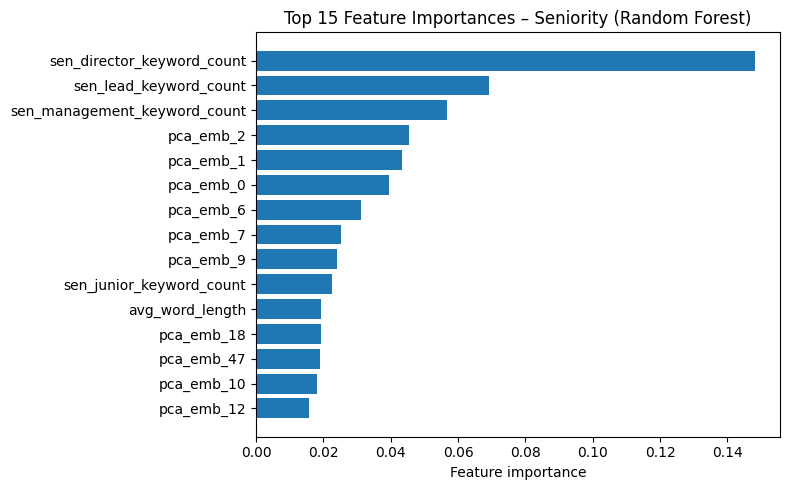

In [ ]:
import matplotlib.pyplot as plt

#feature importances
fi_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": rf_sen.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

#top 15 Features
top_n = 15
top_df = fi_df.head(top_n)

#plot
plt.figure(figsize=(8, 5))
plt.barh(top_df["feature"][::-1], top_df["importance"][::-1])
plt.xlabel("Feature importance")
plt.title("Top 15 Feature Importances – Seniority (Random Forest)")
plt.tight_layout()
plt.show()

In [ ]:
#importance of feature groups
def feature_group(f):
    if f in STRUCT_COLS:
        return "structure"
    if f.startswith("sen_"):
        return "keywords"
    if f.startswith("pca_emb_"):
        return "embeddings"
    return "other"

fi_df["group"] = fi_df["feature"].apply(feature_group)

fi_df.groupby("group")["importance"].sum().sort_values(ascending=False)

,importance
group,
embeddings,0.666565
keywords,0.304569
structure,0.028866


The feature importance analysis shows very consistent and technically plausible model behaviour. The PCA-reduced embeddings make the largest contribution to the prediction with around 67%, confirming that the semantic meaning of the job title is the most important signal for seniority. In addition, the keyword features contribute significantly to the model decision with around 30% and provide clear, easily interpretable seniority indicators. The structural features play only a supporting role, accounting for just under 3%. Overall, the model shows a meaningful combination of implicit semantic information (embeddings) and explicit domain knowledge (keywords), which explains both the high prediction quality and the good explainability of the approach.

**Cosine similarity**

We prepare a lookup base from training data: embeddings, labels, and title texts.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

#training data (embeddings + labels + titel) for lookup
X_train_emb_lookup = X_sen_emb[idx_train_sen]
y_train_lookup = y_sen[idx_train_sen]
text_train_lookup = df_sen["text"].values[idx_train_sen]
text_train_norm_lookup = df_sen["text_norm"].values[idx_train_sen]

print(X_train_emb_lookup.shape, y_train_lookup.shape)

(7542, 384) (7542,)


In [ ]:
def explain_with_cosine_similarity(
    query_emb: np.ndarray,
    top_k: int = 5
) -> pd.DataFrame:
    """
    Returns top-k most similar training titles (example-based explanation).
    query_emb: shape (384,) or (1,384)
    """
    if query_emb.ndim == 1:
        query_emb = query_emb.reshape(1, -1)

    sims = cosine_similarity(query_emb, X_train_emb_lookup).flatten()
    top_idx = sims.argsort()[::-1][:top_k]

    return pd.DataFrame({
        "rank": range(1, top_k + 1),
        "similarity": sims[top_idx],
        "train_label": y_train_lookup[top_idx],
        "train_title": text_train_lookup[top_idx],
        "train_title_norm": text_train_norm_lookup[top_idx],
    })

In [ ]:
j = 0
test_row_idx = idx_test_sen[j]

query_title = df_sen.loc[test_row_idx, "text"]
true_label = df_sen.loc[test_row_idx, "label"]

#embedding for this title (from X_sen_emb)
query_emb = X_sen_emb[test_row_idx]

print("Query title:", query_title)
print("True label:", true_label)

explain_df = explain_with_cosine_similarity(query_emb, top_k=5)
explain_df

Query title: Geschäftsführer / Vertrieb
True label: Management


,rank,similarity,train_label,train_title,train_title_norm
0,1,1.000000,Management,Geschäftsführer/Vertrieb,geschaeftsfuehrer vertrieb
1,2,1.000000,Management,Geschäftsführer - Vertrieb,geschaeftsfuehrer vertrieb
2,3,1.000000,Management,Geschäftsführer Vertrieb,geschaeftsfuehrer vertrieb
3,4,0.969990,Management,Vertriebs Geschäftsführer,vertriebs geschaeftsfuehrer
4,5,0.892041,Management,Tochter Geschäftsführer,tochter geschaeftsfuehrer


The job title was classified as Management because its semantic embedding is highly similar to multiple training examples labeled as Management. The cosine similarity to the top reference titles is 1.0, indicating an almost identical semantic representation. All nearest neighbors correspond to Geschäftsführer roles, providing strong evidence for the predicted seniority level.

In [ ]:
for j in range(len(idx_test_sen)):
    idx = idx_test_sen[j]
    if df_sen.loc[idx, "label"] == "Senior":
        print("Index:", j)
        print("Title:", df_sen.loc[idx, "text"])
        break

Index: 2
Title: Technical Sales Engineer | Grundfos Portugal


In [ ]:
j = 2
test_row_idx = idx_test_sen[j]

query_title = df_sen.loc[test_row_idx, "text"]
true_label = df_sen.loc[test_row_idx, "label"]

query_emb = X_sen_emb[test_row_idx]

print("Query title:", query_title)
print("True label:", true_label)

explain_df = explain_with_cosine_similarity(query_emb, top_k=5)
explain_df

Query title: Technical Sales Engineer | Grundfos Portugal
True label: Senior


,rank,similarity,train_label,train_title,train_title_norm
0,1,0.890913,Senior,Sales Engineer Spain & Portugal,sales engineer spain portugal
1,2,0.806720,Management,CEO / Sales Engineer,ceo sales engineer
2,3,0.748219,Senior,Technical Sales & Support Engineer,technical sales support engineer
3,4,0.729555,Senior,Marketing Engineer,marketing engineer
4,5,0.726975,Senior,Sales Support Engineer,sales support engineer


The job title “Technical Sales Engineer” is classified as Senior because its embedding is most similar to multiple Senior-level Sales Engineer roles. The nearest neighbors are consistently technical and sales-oriented Senior positions, with cosine similarities up to 0.89. Although one management-related title appears among the top neighbors, the overall similarity distribution clearly supports the Senior classification.

# **Department Model**